## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

In [285]:
import pandas as pd

def load_titles(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    dataset_clean = df[["title", "label"]].rename(columns={"title": "text"})
    dataset_clean["label"] = dataset_clean["label"].str.upper().map({"REAL": 1, "FAKE": 0})
    dataset_clean = dataset_clean.dropna(subset=["text", "label"])
    dataset_clean["text"] = dataset_clean["text"].astype(str).str.strip()
    dataset_clean = dataset_clean[dataset_clean["text"] != ""]
    dataset_clean = dataset_clean.drop_duplicates(subset=["text"]).reset_index(drop=True)
    print("fichier sauvegarde : ../data/titles_clean.csv")
    dataset_clean.to_csv("../data/titles_clean.csv", index=False)
    return dataset_clean

In [286]:
dataset_clean = load_titles("../data/fake_or_real_news.csv")
dataset_clean.head()

fichier sauvegarde : ../data/titles_clean.csv


,text,label
0,You Can Smell Hillary’s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


### 1.2 Analyse exploratoire

longueur des titres en tokens
            min  max  median
label_name                  
FAKE (0)      1   53    11.0
REAL (1)      2   27    10.0


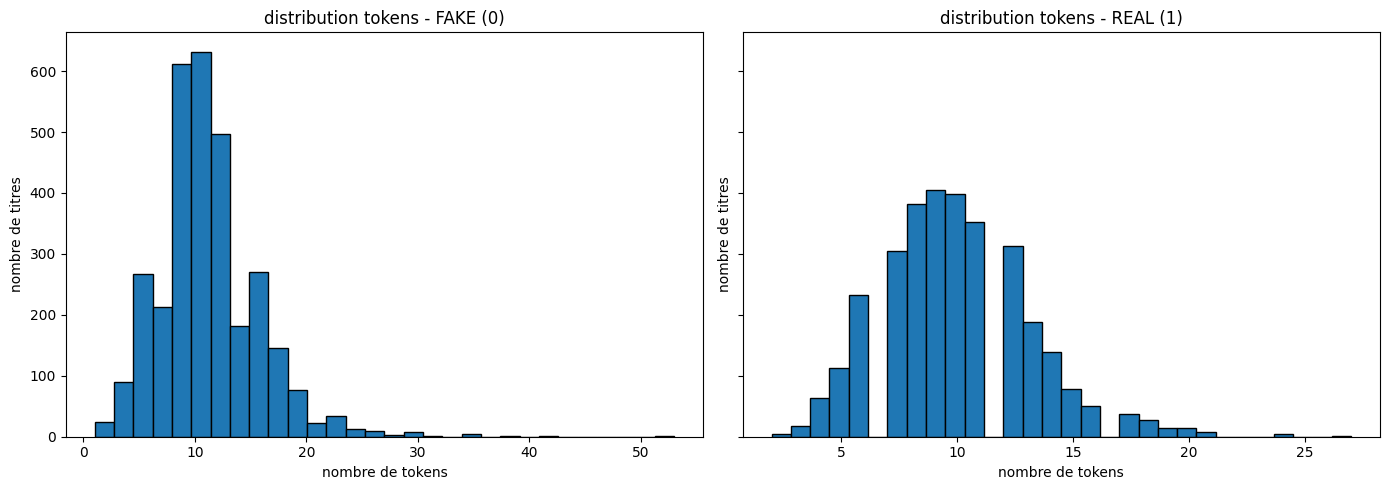

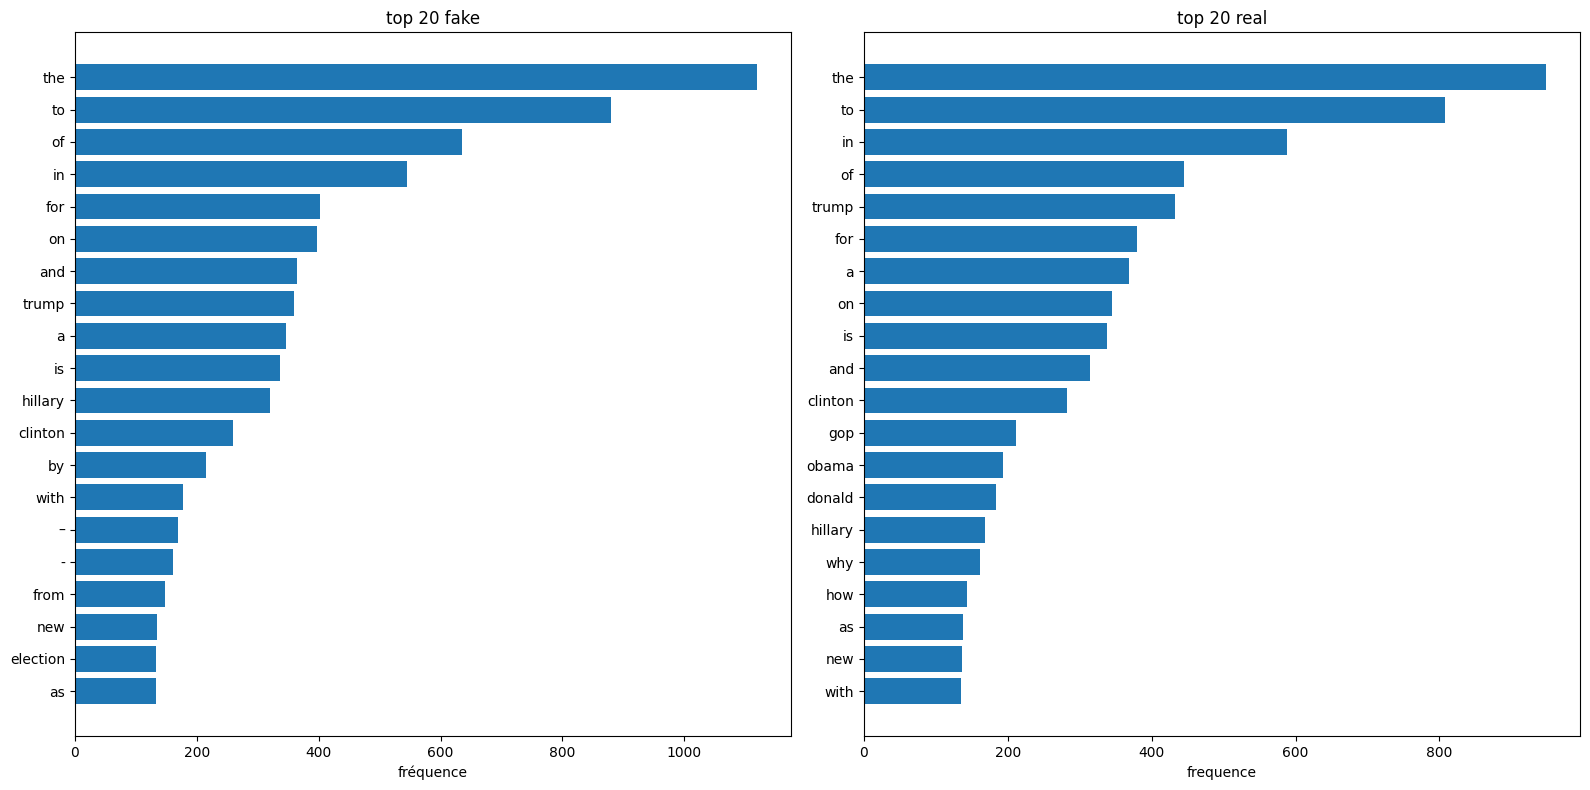

In [287]:
import matplotlib.pyplot as plt
label_names = {0: "FAKE (0)", 1: "REAL (1)"}
df_plot = dataset_clean.copy()
df_plot["label_name"] = df_plot["label"].map(label_names)
df_plot["text_len_tokens"] = df_plot["text"].str.split().str.len()
stats_len = df_plot.groupby("label_name")["text_len_tokens"].agg(["min", "max", "median"]).sort_index()

print("longueur des titres en tokens")
print(stats_len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (label_value, label_name) in zip(axes, [(0, "FAKE (0)"), (1, "REAL (1)")]):
    lengths = df_plot.loc[df_plot["label"] == label_value, "text_len_tokens"]
    ax.hist(lengths, bins=30, edgecolor="black")
    ax.set_title(f"distribution tokens - {label_name}")
    ax.set_xlabel("nombre de tokens")
    ax.set_ylabel("nombre de titres")
plt.tight_layout()
plt.show()

tokens_fake = df_plot.loc[df_plot["label"] == 0, "text"].str.lower().str.split().explode().dropna()
tokens_real = df_plot.loc[df_plot["label"] == 1, "text"].str.lower().str.split().explode().dropna()
top20_fake = tokens_fake.value_counts().head(20).sort_values(ascending=True)
top20_real = tokens_real.value_counts().head(20).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(top20_fake.index, top20_fake.values)
axes[0].set_title("top 20 fake")
axes[0].set_xlabel("fréquence")
axes[1].barh(top20_real.index, top20_real.values)
axes[1].set_title("top 20 real")
axes[1].set_xlabel("frequence")
plt.tight_layout()
plt.show()

In [288]:
tokens_fake = dataset_clean.loc[dataset_clean["label"] == 0, "text"].str.lower().str.split().explode()
tokens_real = dataset_clean.loc[dataset_clean["label"] == 1, "text"].str.lower().str.split().explode()
freq_fake = tokens_fake.value_counts()
freq_real = tokens_real.value_counts()
tokens_purs_fake = freq_fake[~freq_fake.index.isin(freq_real.index)].head(10)
tokens_purs_real = freq_real[~freq_real.index.isin(freq_fake.index)].head(10)

print("10 tokens discriminants - FAKE (0)")
print(tokens_purs_fake)

print("10 tokens discriminants - REAL (1)")
print(tokens_purs_real)

10 tokens discriminants - FAKE (0)
text
:            54
(video)      42
re:          40
truthfeed    33
breaking:    32
finest       30
[video]      26
gold         22
podesta      18
fraud        18
Name: count, dtype: int64
10 tokens discriminants - REAL (1)
text
(+video)        67
jeb             50
marriage        30
rand            24
bid             23
convention      22
hampshire       20
polarization    19
boehner         19
takeaways       19
Name: count, dtype: int64


Trois titres ambigus : 
- ‘Mentally Ill’ Officer: Give Me Back My Gun -> Mentally ill pourrait être repris dans un titre de fake news, propos excessifs, insultes, mise en cause personnelle de politique. Est ce que c'est un faits divers judiciaire, à priori oui. Pourrait être interprété comme une fake news pro NRA. etc... 

- ‘Ignored’ voter to become ‘absolutely shafted’ voter -> shafted est assez familier (grugé ?), on va avoir ce registre de language plutôt dans la presse bas de gamme, spectaculariste. Mais ici c'est une citation, et donc c'est plus ambigu. Les citations rajoutent une couche de complexité car elles introduisent un vocabulaire plus 'oral' dans des titres sérieux. Mais ce type de vocabulaire est plutôt normalement côté fake news. En plus les guillemets sont souvent utilisés comme un élément rhétorique inverse, exemple en France : https://www.francesoir.fr/politique-monde-societe-justice-culture-medias/l-avenir-du-journalisme-appartient-aux-independants dans cet article du très dispensable France-Soir, les guillemets autour de "médias historiques", indique que les journaux en question s'intitulent eux même selon ce vocable. Les guillemets servent à indiquer une ironie, car France-soir se veut le pourfendeur d'une presse soi-disant à la botte des lobbys (notamment le secteur pharmaceutique, France soir étant un journal anti-vax notoire).

- ‘Solar Winds’ Spur Geomagnetic Storm That May Affect Power -> ça fait très SF, sensationnaliste mais en réalité c'est tout à fait crédible.

-‘UFO’ Spotted Over Vienna, Frightened Onlookers Call Police -> les guillemets ici aussi montrent une distance mais pas ironique. Le titre semble sensationnel avec une lecture rapide. Mais à priori ça porte sur un fait réel de citoyens effrayés (et crédules) qui ont appellé la police

- 'There appear to be no rules anymore -> une citation mais pas d'auteurs, peu d'information, court. Est ce un sociologue qui cite un supporter de Trump pour analyser leur besoin d'un leader fort et providentiel ? Ou un article sensationnaliste que la société est devenue décadente car ultra laxiste.
 


## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

In [289]:
CONTRACTIONS: dict[str, str] = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "had'nt": "had not",
    "i'm": "i am",
    "you're": "you are",
    "we're": "we are",
    "they're": "they are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "we'll": "we will",
    "they'll": "they will",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "let's": "let us"
}

def expand_contractions(text: str) -> str:
    text = text.replace("’", "'")
    for short, long in CONTRACTIONS.items():
        text = text.replace(short, long)
    return text

def tokenize_text(text: str) -> list[str]:
    return str(text).split()

exemple = "Where they had'nt. It isn't fake, and they've checked."
print(tokenize_text(expand_contractions(exemple)))

['Where', 'they', 'had', 'not.', 'It', 'is', 'not', 'fake,', 'and', 'they', 'have', 'checked.']


In [290]:
import re

def clean_text(tokens: list[str]) -> list[str]:
    cleaned_tokens: list[str] = []
    for token in tokens:
        token = str(token).lower()
        token = re.sub(r"<[^>]+>|&[a-zA-Z]+;", "", token)
        if re.search(r"https?://\S+|www\.\S+", token):
            continue
        if token.startswith("@") or token.startswith("#"):
            continue
        token = re.sub(r"[^a-zà-öø-ÿ]", "", token)
        if token:
            cleaned_tokens.append(token)
    return cleaned_tokens

exemple = ["Hey", "@jean-mich-mich", "this", "<b>fake</b>!", "https://site.com", "#news-tag", "2024"]
print(clean_text(exemple))

['hey', 'this', 'fake']


In [291]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

NEGATION_WORDS = ["not", "no", "never", "neither"]
EN_STOPWORDS = [word for word in stopwords.words("english") if word not in NEGATION_WORDS]

def remove_stopwords_not_negation(tokens: list[str]) -> list[str]:
    return [token for token in tokens if token not in EN_STOPWORDS]

exemple = ["this", "is", "not", "a", "fake", "news", "and", "we", "never", "trust", "that", "source"]
print(remove_stopwords_not_negation(exemple))

['not', 'fake', 'news', 'never', 'trust', 'source']


In [292]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def lemmatize_text(tokens: list[str]) -> list[str]:
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if token.lemma_.strip()]

exemple = ["striped", "beaches", "fooled", "mice"]
print(lemmatize_text(exemple))

['strip', 'beach', 'fool', 'mouse']


In [293]:
def remove_shorty(tokens: list[str]) -> list[str]:
    return [token for token in tokens if len(token) > 2]

exemple = ["i", "am", "not", "sure", "ok"]
print(remove_shorty(exemple))

['not', 'sure']


In [294]:
def clean_all(text):
    text = tokenize_text(expand_contractions(text))
    text = clean_text(text)
    text = remove_stopwords_not_negation(text)
    text = lemmatize_text(text)
    return remove_shorty(text)

In [295]:
dataset_clean["text_clean"] = dataset_clean["text"].apply(clean_all)
dataset_clean["text_clean_str"] = dataset_clean["text_clean"].str.join(" ")


### 2.2 Mesure de l'impact du nettoyage


In [296]:
tokens_before = dataset_clean["text"].str.split()
tokens_after = dataset_clean["text_clean"]

vocabulary_before = set(tokens_before.explode().dropna())
vocabulayr_after = set(tokens_after.explode().dropna())

len_before = tokens_before.str.len()
len_after = tokens_after.str.len()
reduction_moyenne = (len_before - len_after).mean()

nb_vides = int((len_after == 0).sum())

print("taille vocabulaire avant nettoyage:", len(vocabulary_before))
print("taille vocabulaire apres nettoyage:", len(vocabulayr_after))
print("reduction moyenne de longueur (tokens):", round(reduction_moyenne, 2))
print("titres devenus vides après nettoyage:", nb_vides)


taille vocabulaire avant nettoyage: 17955
taille vocabulaire apres nettoyage: 8128
reduction moyenne de longueur (tokens): 3.28
titres devenus vides après nettoyage: 4


In [297]:
dataset_model = dataset_clean[len_after > 0].copy()
print("taille dataset_model (sans titres vides):", len(dataset_model))

taille dataset_model (sans titres vides): 6252


**Question écrite :** Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

La négation doit être conservée car elle va apporter une différence majeure en terme de sens. "Super" différent de "pas super". Idem "bad" vs "not bad". 
exemples du corpus :
- Donald Trump Is Changing His Campaign Slogan to Prove He’s Not Racist
- No, it's not 'World War 3'

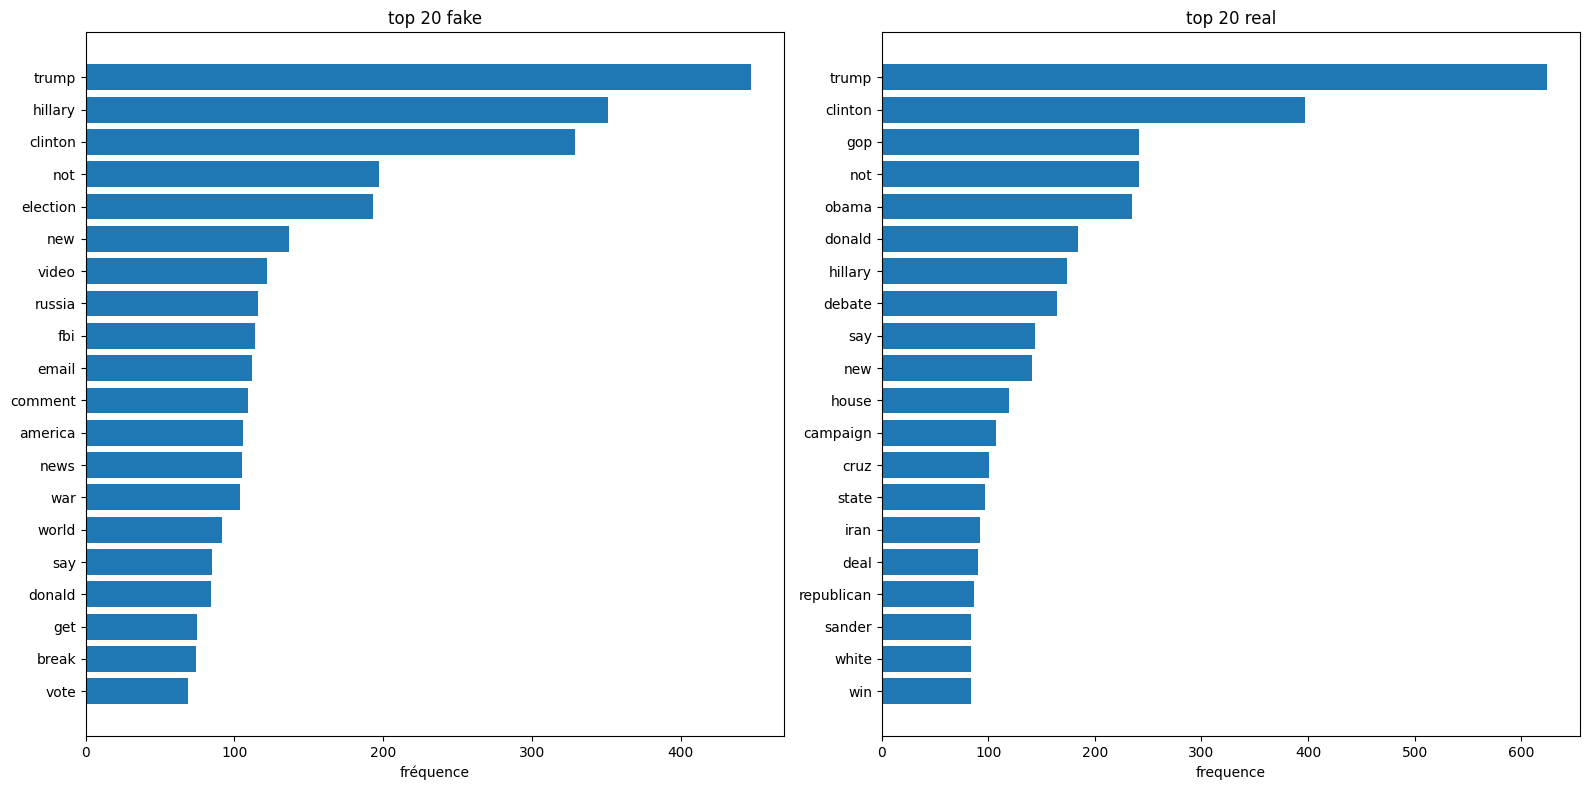

In [298]:

df_plot = dataset_model.copy()

tokens_fake = df_plot.loc[df_plot["label"] == 0, "text_clean_str"].str.lower().str.split().explode().dropna()
tokens_real = df_plot.loc[df_plot["label"] == 1, "text_clean_str"].str.lower().str.split().explode().dropna()

top20_fake = tokens_fake.value_counts().head(20).sort_values(ascending=True)
top20_real = tokens_real.value_counts().head(20).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top20_fake.index, top20_fake.values)
axes[0].set_title("top 20 fake")
axes[0].set_xlabel("fréquence")

axes[1].barh(top20_real.index, top20_real.values)
axes[1].set_title("top 20 real")
axes[1].set_xlabel("frequence")

plt.tight_layout()
plt.show()

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

In [299]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(dataset_model["text_clean_str"])
y = dataset_model["label"]

print("shape X_tfidf:", X_tfidf.shape)
print("number features:", len(vectorizer.get_feature_names_out()))

shape X_tfidf: (6252, 3000)
number features: 3000


In [300]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

X_text = dataset_model["text_clean_str"]
y = dataset_model["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer_tfid = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer_tfid.fit_transform(X_train_text)
X_test = vectorizer_tfid.transform(X_test_text)


print("shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

#save
joblib.dump(vectorizer_tfid, "../models/vectorizer.pkl")


shape X_train: (5001, 3000)
Shape X_test: (1251, 3000)


['../models/vectorizer.pkl']

### 3.2 Embedding avec TensorFlow


In [301]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization
import unicodedata

# traitement similaire a l'autre mais on saute l'etape de lemmatization
def normalize_unicode_text(text: str) -> str:
    value = unicodedata.normalize("NFKC", str(text))
    value = value.replace("\u2019", "'")
    return value.strip()


def clean_for_embedding(text: str) -> str:
    text = normalize_unicode_text(text)
    tokens = tokenize_text(expand_contractions(text))
    tokens = clean_text(tokens)
    tokens = remove_stopwords_not_negation(tokens)
    tokens = remove_shorty(tokens)
    return " ".join(tokens)


X_raw = dataset_model["text"].fillna("").astype(str).map(normalize_unicode_text)
y_raw = dataset_model["label"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

X_train_clean = X_train_raw.apply(clean_for_embedding)
X_test_clean = X_test_raw.apply(clean_for_embedding)

text_vectorizer = TextVectorization(
    max_tokens=5000,
    output_sequence_length=30
)

text_vectorizer.adapt(X_train_clean.values)

X_train_embeddings = text_vectorizer(X_train_clean.values)
X_test_embeddings = text_vectorizer(X_test_clean.values)

print("vocab size:", len(text_vectorizer.get_vocabulary()))
print("shape x_train_seq:", X_train_embeddings.shape)
print("shape x_test_seq:", X_test_embeddings.shape)


vocab size: 5000
shape x_train_seq: (5001, 30)
shape x_test_seq: (1251, 30)


**Question écrite :** Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez.

TF-idf représente les documents de façon statistique, la valeur d'un mot dépend de sa  fréquence dans l'ensemble -> il n'y a pas de lien entre les mots. Les embeddings sont des représentations denses ajoutant du contexte (des mots proches). Donc on peut rapprocher des mots entre eux, et leur attribuer une zone proche (d'un point de vue vectoriel). Comme on utilise des vecteurs de valeur on peut effectuer des opérations vectorielles (exemple courant : roi - homme + femme = reine). Mais ça reste une approximation, une zone vectorielle plus qu'un point précis.


## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

In [302]:
import time

def timed(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    
    execution_time = end - start
    return result, execution_time

In [303]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

X_train_tfidf = X_train.toarray()
X_test_tfidf = X_test.toarray()
y_train_tfidf = y_train.to_numpy()
y_test_tfidf = y_test.to_numpy()

model_tfidf = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_tfidf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    ModelCheckpoint("../models/best_model.keras", monitor="val_loss", save_best_only=True)
]

history_tfidf, tfidf_train_time = timed(
            model_tfidf.fit,
            X_train_tfidf,
            y_train_tfidf,
            epochs=30,
            validation_split=0.15,
            callbacks=callbacks,
            batch_size=32,
            verbose=1
)

test_loss, test_accuracy = model_tfidf.evaluate(X_test_tfidf, y_test_tfidf, verbose=0)
print("test loss:", test_loss)
print("test accuracy:", test_accuracy)

Epoch 1/30


c:\Users\Administrateur\projects\ecf4\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6965 - loss: 0.6026 - val_accuracy: 0.8043 - val_loss: 0.4106
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8621 - loss: 0.3283 - val_accuracy: 0.8096 - val_loss: 0.4012
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9235 - loss: 0.1932 - val_accuracy: 0.8189 - val_loss: 0.4567
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9602 - loss: 0.1071 - val_accuracy: 0.8162 - val_loss: 0.5138
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9861 - loss: 0.0502 - val_accuracy: 0.8109 - val_loss: 0.6246
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9936 - loss: 0.0262 - val_accuracy: 0.8136 - val_loss: 0.7089
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9967 - loss: 0.0148 - val_accuracy: 0.8109 - val_loss: 0.7830
test loss: 0.45958176255226135
test accuracy: 0.7769784331321716


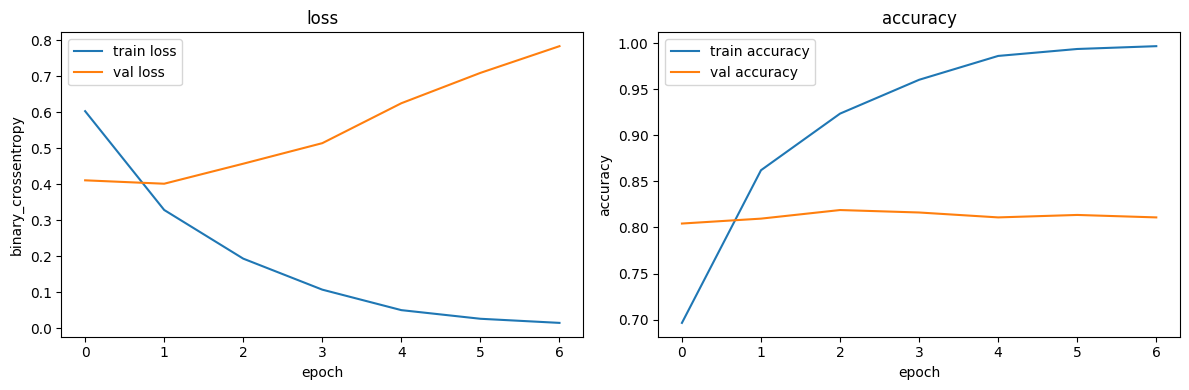

In [304]:
import matplotlib.pyplot as plt

history_dict = history_tfidf.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["loss"], label="train loss")
plt.plot(history_dict["val_loss"], label="val loss")
plt.title("loss")
plt.xlabel("epoch")
plt.ylabel("binary_crossentropy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["accuracy"], label="train accuracy")
plt.plot(history_dict["val_accuracy"], label="val accuracy")
plt.title("accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### 4.2 Modèle avec embeddings appris — architecture séquentielle


In [305]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

X_train_embbedings = X_train_clean.to_numpy()
X_test_embbedings = X_test_clean.to_numpy()
y_train_embbedings = y_train_raw.astype("float32").to_numpy()
y_test_embbedings = y_test_raw.astype("float32").to_numpy()

model_embedding = Sequential([
    text_vectorizer,
    Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_embedding.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_embedding = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    ModelCheckpoint("../models/best_model_embedding.keras", monitor="val_loss", save_best_only=True)
]

history_embedding, embedding_train_time = timed(
    model_embedding.fit,
    X_train_embbedings,
    y_train_embbedings,
    epochs=30,
    validation_split=0.15,
    callbacks=callbacks_embedding,
    batch_size=32,
    verbose=1
)

test_loss_emb, test_accuracy_emb = model_embedding.evaluate(X_test_embbedings, y_test_embbedings, verbose=0)
print("test loss embedding:", test_loss_emb)
print("test accuracy embedding:", test_accuracy_emb)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6929 - loss: 0.5671 - val_accuracy: 0.8202 - val_loss: 0.4117
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8868 - loss: 0.2880 - val_accuracy: 0.8149 - val_loss: 0.4041
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9405 - loss: 0.1525 - val_accuracy: 0.8123 - val_loss: 0.5881
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9704 - loss: 0.0917 - val_accuracy: 0.8029 - val_loss: 0.6982
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9826 - loss: 0.0550 - val_accuracy: 0.7963 - val_loss: 0.8433
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9868 - loss: 0.0376 - val_accuracy: 0.7949 - val_loss: 1.0635
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9906 - loss: 0.0285 - val_accuracy: 0.8083 - val_loss: 1.0204
test loss embedding: 0.4263976514339447
test accuracy embedding: 0.8009592294692993


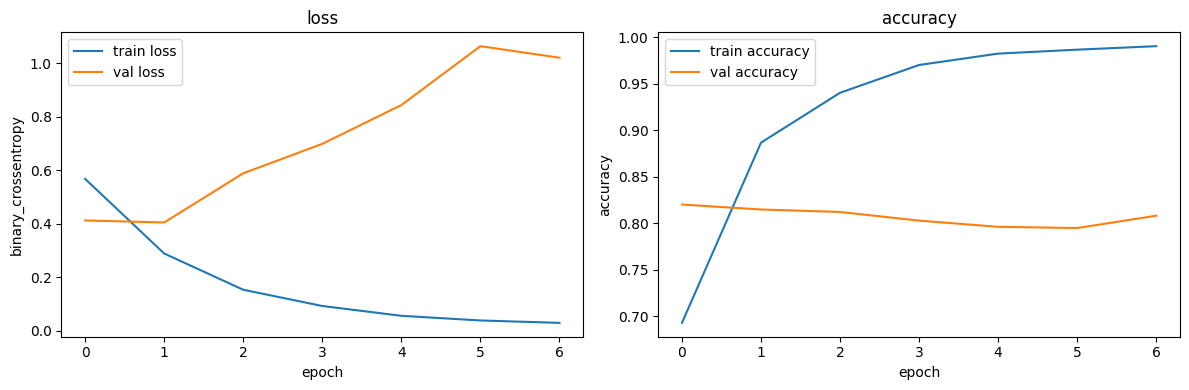

In [306]:
import matplotlib.pyplot as plt

history_dict_emb = history_embedding.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict_emb["loss"], label="train loss")
plt.plot(history_dict_emb["val_loss"], label="val loss")
plt.title("loss")
plt.xlabel("epoch")
plt.ylabel("binary_crossentropy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict_emb["accuracy"], label="train accuracy")
plt.plot(history_dict_emb["val_accuracy"], label="val accuracy")
plt.title("accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### 4.3 Comparaison des deux architectures


In [307]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_proba_tfifd = model_tfidf.predict(X_test_tfidf, verbose=0)[:, 0]
y_pred_tfidf = (y_proba_tfifd >= 0.5).astype(int)

y_proba_embbedings = model_embedding.predict(X_test_embbedings, verbose=0)[:, 0]
y_pred_embbedings = (y_proba_embbedings >= 0.5).astype(int)

metrics_tfidf = {
    "Accuracy (test)": accuracy_score(y_test_tfidf, y_pred_tfidf),
    "Precision — classe FAKE": precision_score(y_test_tfidf, y_pred_tfidf, pos_label=0),
    "Recall — classe FAKE": recall_score(y_test_tfidf, y_pred_tfidf, pos_label=0),
    "F1-score (macro)": f1_score(y_test_tfidf, y_pred_tfidf, average="macro"),
    "AUC-ROC": roc_auc_score(y_test_tfidf, y_proba_tfifd),
    "Epochs effectifs (EarlyStopping)": len(history_tfidf.history["loss"]),
    "Nombre de paramètres entraînables": model_tfidf.count_params(),
    "Temps entrainement (approx.)": tfidf_train_time
}

metrics_embbedings = {
    "Accuracy (test)": accuracy_score(y_test_embbedings, y_pred_embbedings),
    "Precision — classe FAKE": precision_score(y_test_embbedings, y_pred_embbedings, pos_label=0),
    "Recall — classe FAKE": recall_score(y_test_embbedings, y_pred_embbedings, pos_label=0),
    "F1-score (macro)": f1_score(y_test_embbedings, y_pred_embbedings, average="macro"),
    "AUC-ROC": roc_auc_score(y_test_embbedings, y_proba_embbedings),
    "Epochs effectifs (EarlyStopping)": len(history_embedding.history["loss"]),
    "Nombre de paramètres entraînables": model_embedding.count_params(),
    "Temps entrainement (approx.)": embedding_train_time
}

table = pd.DataFrame({
    "Critère": list(metrics_tfidf.keys()),
    "Modèle Dense (TF-IDF)": list(metrics_tfidf.values()),
    "Modèle LSTM Bidirectionnel": list(metrics_embbedings.values())
})

table

,Critère,Modèle Dense (TF-IDF),Modèle LSTM Bidirectionnel
0,Accuracy (test),0.776978,0.800959
1,Precision — classe FAKE,0.801056,0.799035
2,Recall — classe FAKE,0.732689,0.800322
3,F1-score (macro),0.776429,0.800951
4,AUC-ROC,0.878350,0.884680
5,Epochs effectifs (EarlyStopping),7.000000,7.000000
6,Nombre de paramètres entraînables,801281.000000,394369.000000
7,Temps entrainement (approx.),3.974073,22.719003


**Question écrite :** Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

- à noter en l'état actuel des choses, les deux modèles manquent d'optimisation et présentent tout les deux un problème net d'overfitting mis en lumière dans les deux jeux de graphes précédents. Cet overfitting est limité par la mécanique d'early stopping. 
- accuracy : avantage léger TF-idf
- Prcision : idem léger avantage
- recall : avantage assez net au LSTM, cette métrique est sans doute la plus importante ici. On cherche à maximiser les découvertes de positifs, dans un contexte d'identification. Le rôle primordial de l'api sera de repérer les fakes news.
- Epochs, early stopping assez précoce dans les deux cas
- params : net avantage au LSTM, on peut supposer qu'un nombre plus faible de paramètres permettra de meilleurs performances (mémoire notamment) durant l'exploitation. 
- temps d'entrainement : net avantage pour le TFIDF, mais le temps d'entrainement n'est pas ici une mesure significative. (Même en multipliant le nombre de données, on restera sur un coût d'entrainement acceptable). Le coût d'entrainement n'étant pas pertinent pour évaluer l'impact en production.

### Toutefois suite à un souci d'encodage de dernière minute non résolu (peut être lié à Windows ?), c'est le modèle TFIDF qui sera utilisé dans l'API.

## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle

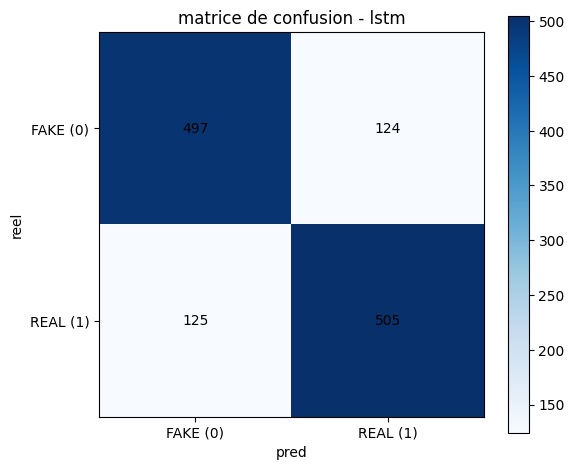

classification report - model_embedding
              precision    recall  f1-score   support

        FAKE       0.80      0.80      0.80       621
        REAL       0.80      0.80      0.80       630

    accuracy                           0.80      1251
   macro avg       0.80      0.80      0.80      1251
weighted avg       0.80      0.80      0.80      1251



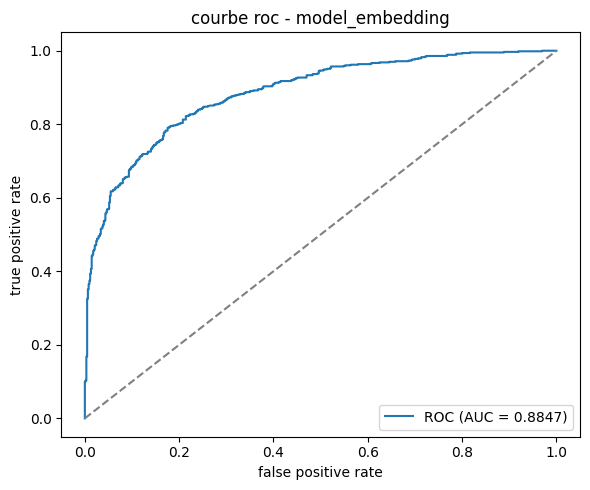

auc roc: 0.8846803670475168


In [308]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

y_proba_best = model_embedding.predict(X_test_embbedings, verbose=0)[:, 0]
y_pred_best = (y_proba_best >= 0.5).astype(int)

cm = confusion_matrix(y_test_embbedings, y_pred_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("matrice de confusion - lstm")
plt.colorbar()

classes = ["FAKE (0)", "REAL (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel("pred")
plt.ylabel("reel")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

print("classification report - model_embedding")
print(classification_report(y_test_embbedings, y_pred_best, target_names=["FAKE", "REAL"]))

fpr, tpr, _ = roc_curve(y_test_embbedings, y_proba_best)
auc_score = roc_auc_score(y_test_embbedings, y_proba_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("courbe roc - model_embedding")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("auc roc:", auc_score)

### 5.2 Analyse des erreurs


In [309]:
proba = model_embedding.predict(X_test_embbedings, verbose=0)[:, 0]
pred = (proba >= 0.5).astype(int)
true = y_test_embbedings.astype(int)

df = pd.DataFrame({
    "title_brut": X_test_raw.values,
    "true": true,
    "pred": pred,
    "proba": proba
})

fp = df[(df["true"] == 1) & (df["pred"] == 0)].nsmallest(15, "proba") # la proba mesure la probabilité que le titre soit true (REAL), les titres classés les plus proche de FAKE ont donc la proba la plus faible

fn = df[(df["true"] == 0) & (df["pred"] == 1)].nlargest(15, "proba") # et inversement

print("15 faux positifs (real -> predit fake)")
for _, row in fp.iterrows():
    print(f"true={int(row['true'])} pred={int(row['pred'])} proba_real={row['proba']:.4f} | {row['title_brut']}")

print()

print("15 faux négatifs (fake -> predit real)")
for _, row in fn.iterrows():
    print(f"true={int(row['true'])} pred={int(row['pred'])} proba_real={row['proba']:.4f} | {row['title_brut']}")

15 faux positifs (real -> predit fake)
true=1 pred=0 proba_real=0.0192 | Hot dogs, bacon and other processed meats cause cancer, World Health Organization declares
true=1 pred=0 proba_real=0.0375 | James O'Keefe releases another Project Veritas video claiming Hillary Clinton campaign is “bird dogging”
true=1 pred=0 proba_real=0.0464 | What 20,000 pages of hacked WikiLeaks emails teach us about Hillary Clinton
true=1 pred=0 proba_real=0.0771 | Giuliani, suggesting Trump may have ‘exaggerated' in lewd comments, says, ‘talk and action are two different things'
true=1 pred=0 proba_real=0.0815 | Who rules the world? America is no longer the obvious answer
true=1 pred=0 proba_real=0.0871 | Life Among the Berned
true=1 pred=0 proba_real=0.0873 | Profit sharing was supposed to be a silver bullet for middle-class success. What happened?
true=1 pred=0 proba_real=0.0980 | Turkey Says It Shot Down A Russian Warplane Near Border With Syria
true=1 pred=0 proba_real=0.0984 | Would Earth Day's creator

Le dataset est fortement aux présidentielles américaines de 2016. Si on sait dorénavant que les démocrates ont été plus ciblés, le vocabulaire relatif aux candidats (Trum, Clinton, Hillary, Obama) n'est finalement pas si discriminant. Hormis peut-être pour "Hillary", le prénom seul est davantage utilisé dans les fake news (voir le graphe sur le vocabulaire nettoyé).

Faux positif : on a un surapprentissage assez net sur certains mots (Russia, FBI). Souvent repris en fake news, ce sont néanmoins de acteurs bien réels. Il est également possible que nous ayons un surapprentissage sur les structures de phrase interrogative. On retrouve aussi des citations, qui ont tendance à perturber le modèle. L'emploi de certains superlatifs (massive) pourrait inciter le modèle à classifier vers FAKE, mais là encore ce n'est pas net.

Faux négatif : on retrouve finalement un certain nombre de structures communes aux faux positifs :  citations, noms des politiques, etc... On peut noter que les titres sont ici parfois plus courts, et donne uniquement de l'information qui semble factuelle. Ce qui correspond plus au style direct des journaux sensationnalistes/tabloids. Toutefois le modèle n'a aucun moyen de vérifier quand le titre est très informatif ("Top EU Official Disputes That Trump Could Upend Iran Nuclear Deal", compliqué de voir la fake news ici).

Le souci est que notre modèle en s'appuyant sur les titres n'apprend pas uniquement le fait que le titre soit une fake news. Il apprend en réalité que certaines structures de language sont typiques des fake news. Lorsque le titre sort de cette typologie, le model n'est plus fiable. Une information peut être vraie et présenté de façon racileuse, à l'inverse, une fause information peut être présentée avec sobriété.


### 5.3 Robustesse


In [310]:
import tensorflow as tf

titles_test = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

titles_clean = [clean_for_embedding(t) for t in titles_test]
pred_matrix = model_embedding(tf.constant(titles_clean), training=False).numpy()
proba_real = [float(x[0]) for x in pred_matrix]

for i, title in enumerate(titles_test, 1):
    p = proba_real[i - 1]
    label = "REAL" if p >= 0.5 else "FAKE"
    print(f"{i}. {label} ({p:.4f}) | {title}")

1. REAL (0.6024) | Scientists discover new treatment for common disease
2. FAKE (0.0531) | SHOCKING: Government hiding truth about water supply
3. FAKE (0.1753) | Local elections results announced in three counties
4. FAKE (0.3422) | You won't believe what this celebrity did last night
5. FAKE (0.2939) | Central bank raises interest rates by 0.25 points
6. FAKE (0.0897) | This one weird trick cures all allergies naturally
7. REAL (0.5449) | Parliament votes on new environmental legislation
8. REAL (0.7681) | Doctors don't want you to know this secret remedy
9. FAKE (0.0853) | Tech company reports quarterly earnings below forecast
10. FAKE (0.2503) | EXCLUSIVE: Famous actor reveals hidden agenda of elites


- 1 - classé REAl, à priori exact mais modèle hésitant, sans doute trop factuel
- 2 - FAKE, OK, "SCHOKING" bien identifié comme sensationnaliste, champ lexical de la dissimulation
- 3 - Classé fake, trop factuel, pas assez d'infos
- 4 - Bien identifié mais limite "will not believe" sns doute discriminat
- 5 - Erreur, mais hésitant, peu d'info et factuel
- 6 - Fake bien identifiée avec sureté (weyrd, naturally), vocabulaire peu précis et connoté
- 7 - Grosse erreur, encore une fois factuel et court
- 8 - Erreur importante, même si la certitude n'est pas si importante, difficile d'identifier pourquoi le modèle identifie la 6 et pas celle-ci
- 9 - Erreur importante, titre court et factuel
- 10 - pattern sensationnaliste bien identifié

60% de réussite, pas exceptionnel, toutefois les fakes news sont bien identifiés 4 fois sur 5

## Partie 6 — Exposition via API REST

voir README.md pour lancer l'api